# Two-segment cantilever beam vibration (Timoshenko, 1D)

This example follows the repository's *example-problem* layout. It generates full-order mode-shape snapshots by solving a generalized eigenproblem and then runs a POD-ROM on the first mode shape.


## Environment setup


In [1]:
import sys
from pathlib import Path
import importlib

nb_folder = Path().resolve()
PROBLEM_NAME = nb_folder.name
parent_folder = nb_folder.parent
if str(parent_folder) not in sys.path:
    sys.path.insert(0, str(parent_folder))


In [2]:
# Standard imports used across examples
from skrom.utils.imports import *
from skrom.rom.rom_utils import *
from skrom.rom.rom_error_est_t import *
from skrom.utils.reduced_basis.svd import svd_mode_selector
import skrom.problem_classes.static.master_class as master

# Register problem (runs @register_problem)
problem_mod = importlib.import_module(f"{PROBLEM_NAME}.problem_def")


PETSc available: True


In [3]:
import sci_mplstyle_package

## Full-order snapshot generation


In [4]:
generate = False
if generate:
    sim = master.fom_simulation(num_snapshots=32)
    sim.run_simulation()


## Load snapshots and build POD basis


In [5]:
from numpy import load

rom_dir = Path('ROM_data')
sim_data = load(rom_dir / 'ROM_simulation_data.npz', allow_pickle=True)
fos_solutions = np.load(rom_dir / 'fos_solutions.npy', allow_pickle=True)

param_list = np.asarray(sim_data['param_list'])
train_mask = sim_data['train_mask']
test_mask = sim_data['test_mask']

LS_train = np.asarray(fos_solutions)[train_mask]
LS_test  = np.asarray(fos_solutions)[test_mask]

# For eigenmodes, use a zero reference to avoid mean-cancel issues
train_ref = np.zeros(LS_train.shape[1])
LS_train_ms = LS_train - train_ref


Number of modes selected: 7


Text(0.5, 0, 'POD modes ($k$)')

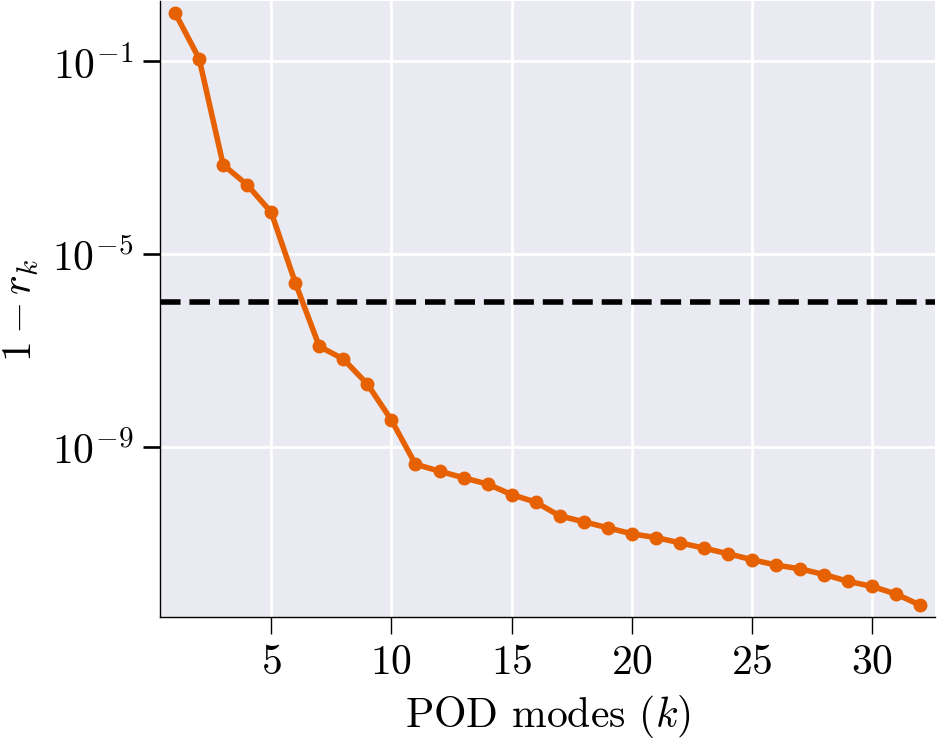

In [6]:
plt.rcParams['lines.markersize'] = 6
plt.rcParams['lines.linewidth'] = 2.0

n_sel, U = svd_mode_selector(LS_train_ms, tolerance=1e-6, modes=True)
V_sel = U[:, :n_sel]

plt.ylabel('$1-r_{k}$')
plt.xlabel('POD modes ($k$)')

## Online ROM evaluation


In [7]:
rom = master.rom_simulation(V_sel=V_sel, train_ref=train_ref)
rom_error, speed_up = rom.run_rom_simulation()
print('Mean ROM error (%):', np.mean(rom_error))
print('Median speed-up:', np.median(speed_up))


[load_rom_data] loaded from d:\One_drive_folder\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\IIT_ISM\RESEARCH\SCIKIT-ROM\scikit-rom\examples\computational_mechanics\dynamic\linear\problem_beam_vibration\ROM_data
Snap 1/64 params=[0.01957787 0.01758242]
Snap 2/64 params=[0.02462353 0.02620061]
Snap 3/64 params=[0.02623145 0.01306602]
Snap 4/64 params=[0.01112964 0.02073685]
Snap 5/64 params=[0.01268571 0.01163499]
Snap 6/64 params=[0.02779974 0.02458914]
Snap 7/64 params=[0.02181502 0.01647373]
Snap 8/64 params=[0.01676203 0.02973056]
Snap 9/64 params=[0.01617364 0.01437028]
Snap 10/64 params=[0.0211485  0.02200218]
Snap 11/64 params=[0.02956    0.01888677]
Snap 12/64 params=[0.01468036 0.02746585]
Snap 13/64 params=[0.01187425 0.01516208]
Snap 14/64 params=[0.02674169 0.02845799]
Snap 15/64 params=[0.02270705 0.01032339]
Snap 16/64 params=[0.01773951 0.02331651]
Snap 17/64 params=[0.0184901  0.01119303]
Snap 18/64 params=[0.02352386 0.02258466]
Snap 19/64 pa

In [10]:
#Assign values for the statistics
LS_rom = np.asarray(rom.rom_solutions)
ROM_speed_up = rom.speed_up
ROM_relative_error = rom.rom_error

In [11]:
# --- ROM error analysis ---

# Compute a flat matrix of error metrics comparing true nonlinear solutions to hyper-ROM approximations
matrix = compute_rom_error_metrics_flat(LS_test, LS_rom)


In [12]:
generate_rom_error_report(matrix)

ROM Accuracy Report

Global Errors:
L2 Error:                        9.1743e-04
Relative L2 Error:               8.4420e-07
L∞ Error:                        3.9329e-06
Relative L∞ Error:               1.9497e-06
RMSE:                            7.1673e-07
MAE:                             4.1923e-07

Statistical Fit:
R² Score:                        1.0000
Explained Variance:              1.0000

Error Distribution (absolute):
Median Abs Error:                1.8839e-07
95th Percentile Abs Error:       1.6576e-06

Time/Parameter-Dependent Errors:
Average Relative L2 over samples:        6.6330e-07
Max Relative L2 over samples:            1.9030e-06
Min Relative L2 over samples:            6.8982e-08
————————————————————————————————————————————————————————————————————————————————————————————————————————————————————————


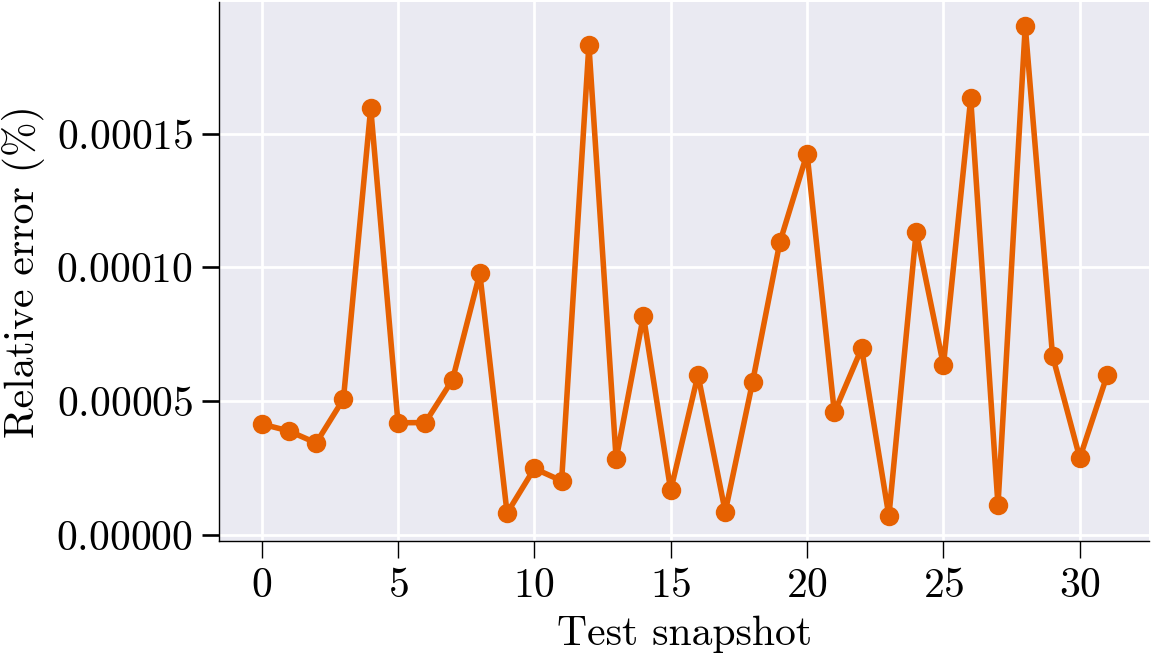

In [8]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(rom_error, '-o')
ax.set_xlabel('Test snapshot')
ax.set_ylabel('Relative error (%)')
ax.grid(True)
plt.show()


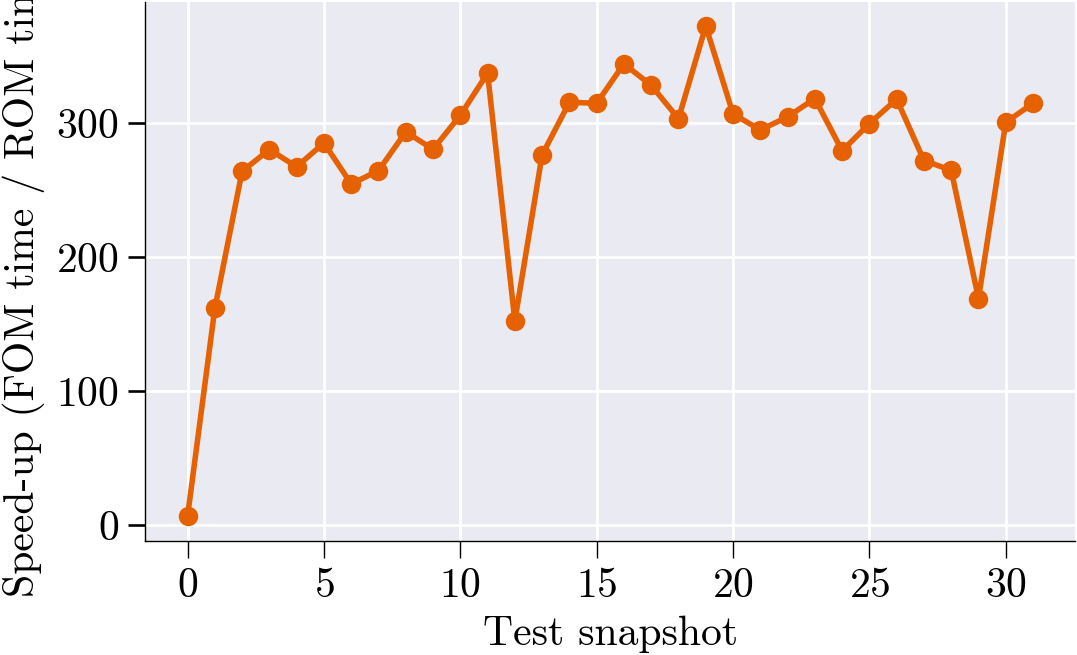

In [9]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(speed_up, '-o')
ax.set_xlabel('Test snapshot')
ax.set_ylabel('Speed-up (FOM time / ROM time)')
ax.grid(True)
plt.show()
